<a href="https://colab.research.google.com/github/mlmisha/BIOCAD_TEST/blob/main/BC_test_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Импорты

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier

При выборе модели я еще пробовал простую логистическую регрессию и случайный лес, но градиентный бустинг все же показал себя лучше всего

#Данные

In [ ]:
!wget https://life.bsc.es/pid/skempi2/database/download/skempi_v2.csv

--2025-05-02 09:21:23--  https://life.bsc.es/pid/skempi2/database/download/skempi_v2.csv
Resolving life.bsc.es (life.bsc.es)... 84.88.52.107
Connecting to life.bsc.es (life.bsc.es)|84.88.52.107|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1602208 (1.5M) [text/csv]
Saving to: ‘skempi_v2.csv’

skempi_v2.csv       100%[===================>]   1.53M  1.82MB/s    in 0.8s    

2025-05-02 09:21:25 (1.82 MB/s) - ‘skempi_v2.csv’ saved [1602208/1602208]



In [ ]:
data = pd.read_csv("/content/skempi_v2.csv",sep = ";")
data

,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_type,Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,...,koff_mut_parsed,koff_wt (s^(-1)),koff_wt_parsed,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),Notes,Method,SKEMPI version
0,1CSE_E_I,LI45G,LI38G,COR,Pr/PI,Pr/PI,5.26E-11,5.260000e-11,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
1,1CSE_E_I,LI45S,LI38S,COR,Pr/PI,Pr/PI,8.33E-12,8.330000e-12,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
2,1CSE_E_I,LI45P,LI38P,COR,Pr/PI,Pr/PI,1.02E-07,1.020000e-07,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
3,1CSE_E_I,LI45I,LI38I,COR,Pr/PI,Pr/PI,1.72E-10,1.720000e-10,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
4,1CSE_E_I,LI45D,LI38D,COR,Pr/PI,Pr/PI,1.92E-09,1.920000e-09,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7080,3QIB_ABP_CD,KP9R,KP8R,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",2.4E-04,2.400000e-04,5.5E-06,5.500000e-06,...,0.500,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2
7081,3QIB_ABP_CD,TP12A,TP11A,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",>1.1E-03,1.100000e-03,5.5E-06,5.500000e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SPR,2
7082,3QIB_ABP_CD,TP12S,TP11S,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",3.38E-05,3.380000e-05,5.5E-06,5.500000e-06,...,0.134,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2
7083,3QIB_ABP_CD,TP12N,TP11N,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",4.34E-05,4.340000e-05,5.5E-06,5.500000e-06,...,0.175,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2


Используя данные из колонок Affinity_mut_parsed и Affinity_wt_parsed вычислим
значения и, соответсвтенно, знаки ddG

Первым делом вычислим значения dG для мутанта и дикого типа, исходя из формулы:

$\Delta G = RTlnKd$


In [ ]:
dG_mut = 8.314*298*np.log(data["Affinity_mut_parsed"])
dG_wt = 8.314*298*np.log(data["Affinity_wt_parsed"])

Значение $\Delta \Delta G$ получим вычитанием $\Delta G_{mut}$  из $\Delta G_{wt}$

In [ ]:
ddG = dG_wt - dG_mut

Создадим колонку в таблице, в которой будет содержаться знак $\Delta \Delta G$. А точнее, достаточно будет значений True/False на + и -, соответственно

In [ ]:
data["ddG_sign"] = ddG>0

Теперь нужно выделить признаки, на которых будет обучаться модель. Кажется, осмысленным учитывать положение мутации (iMutation_Location), тип белкового комплекса (Hold_out_type) и тип замены. Тип замены в таблице содержит в себе еще номер остатка и название цепи, что, без учета собственно структуры белка, которой в таблице нет, мне представляется, малоинформативным и мешающим генерализации. Поэтому я бы преобразовал эти данные так, чтобы в них содержалась просто информация о том какая ак была изначально и на что ее заменили. При этом мутации не обязательно единычны - их может быть несколько штук и даже 26

Text(0.5, 0, 'Число мутаций')

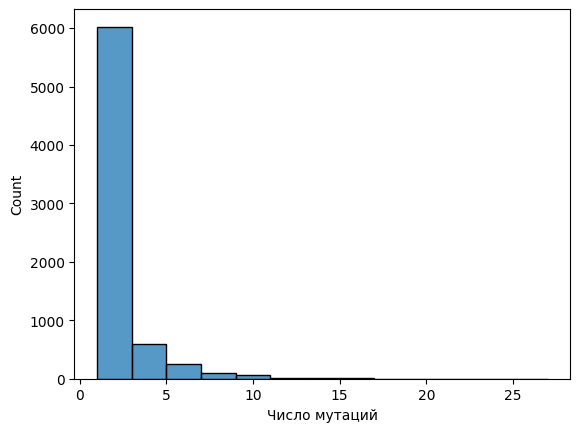

In [ ]:
sns.histplot(data = data["Mutation(s)_PDB"].str.split(",").apply(len), binwidth=2)
plt.xlabel("Число мутаций")

Пока не знаю, как разумно включить данные с несколькими заменами в датасет, поэтому оставлю только те записи, в которых есть всего одна замена

Так как информация о положении остатка мне представляется малоинформативной без информации о структуре белка, я решил удалить этот признак из таблицы, сфокусировавшись только на том, как изменилась аминокислота. Сначала я решил проверить качество модели при представлении этой информации в одной колонке вида "АК_доАК_после", например, замена лейцина на глицин была бы "LG". Я предположил, что так модель будет точнее анализировать всю мутацию, а не будет запоминать, например, только финальную аминокислоту. Однако, качество модели в таком случае оказалось заметно ниже. Ей не удавалось достаточно точно определять мутации, приводящие к повышению энергии. Так что я все жа разбил информацию о мутации на две колонки: "аминокислота до" и "аминоксилота после"

In [ ]:
data_sep = data[data["Mutation(s)_PDB"].str.split(",").apply(len) == 1]
data_sep["Before"] = data_sep["Mutation(s)_PDB"].str[0]
data_sep["After"] = data_sep["Mutation(s)_PDB"].str[-1]

data_sep = data_sep[["Before", "After", "Hold_out_type", "iMutation_Location(s)","ddG_sign",]].dropna().reset_index()
data_sep

<ipython-input-17-d8a7c025ce3f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sep["Before"] = data_sep["Mutation(s)_PDB"].str[0]
<ipython-input-17-d8a7c025ce3f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sep["After"] = data_sep["Mutation(s)_PDB"].str[-1]


,index,Before,After,Hold_out_type,iMutation_Location(s),ddG_sign
0,0,L,G,Pr/PI,COR,False
1,1,L,S,Pr/PI,COR,False
2,2,L,P,Pr/PI,COR,False
3,3,L,I,Pr/PI,COR,False
4,4,L,D,Pr/PI,COR,False
...,...,...,...,...,...,...
2411,7079,K,A,TCR/pMHC,COR,False
2412,7080,K,R,TCR/pMHC,COR,False
2413,7081,T,A,TCR/pMHC,COR,False
2414,7082,T,S,TCR/pMHC,COR,False


In [ ]:
X = data_sep.drop("ddG_sign", axis = 1)
y = data_sep["ddG_sign"]
X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 11, stratify=y)

#Модель

Перед разбиением данных на train и test проверил баланс классов

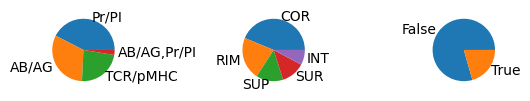

In [ ]:
fig, ax = plt.subplots(1,3)
plt.tight_layout(pad = 5)

ax[0].pie(data_1["Hold_out_type"].value_counts(), labels = data_1["Hold_out_type"].value_counts().index)
ax[1].pie(data_1["iMutation_Location(s)"].value_counts(), labels = data_1["iMutation_Location(s)"].value_counts().index)
ax[2].pie(data_1["ddG_sign"].value_counts(), labels = data_1["ddG_sign"].value_counts().index)
plt.show()

Классы предсказываемой переменной сильно несбалансированы: мутаций, уменьшающих сродство, намного больше. Это надо будет учесть при разбиении. Также сильно несбаланисрованы классы в Hold_out_type и iMutation_Location(s), что может быть опасно

In [ ]:
X = data_sep.drop("ddG_sign", axis = 1)
y = data_sep["ddG_sign"]

X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 11, stratify=y)

In [1]:
from sklearn.metrics import f1_score

In [ ]:
grad_cl_sep = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.05)

grad_cl_sep.fit(X_train, y_train)
grad_cl_sep_pred = grad_cl_sep.predict(X_test)

print(classification_report(y_test, grad_cl_sep_pred))

В качестве контрольной метрики я смотрел на F1-score, поскольку классы y сильно несбалансированы и accuracy может быть искусственно завышен

Попробовал еще повысить качество подобрав гипераматеры. Делаю это с помощью GridSearchCV

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle= True, random_state= 11)

In [ ]:
params = {'max_depth': np.arange(2, 8),
         'min_samples_leaf': np.arange(2, 8)}

Количество гиперпараметров небольшое, так что использую GridSearchCV

In [ ]:
from sklearn.metrics import f1_score, make_scorer

f1 = make_scorer(f1_score , average='weighted')#так как несбалансированные классы

In [ ]:
best_model = GridSearchCV(estimator= grad_cl_sep, param_grid= params,
                         cv= skf, verbose= True, n_jobs= -1, scoring = f1)
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=11, shuffle=True),
             estimator=RandomForestClassifier(max_depth=5, min_samples_leaf=2,
                                              n_estimators=1000),
             n_jobs=-1,
             param_grid={'max_depth': array([2, 3, 4, 5, 6, 7]),
                         'min_samples_leaf': array([2, 3, 4, 5, 6, 7])},
             scoring=make_scorer(f1_score, response_method='predict', average=weighted),
             verbose=True)

In [ ]:
best_model.best_params_

{'max_depth': np.int64(7), 'min_samples_leaf': np.int64(4)}

In [ ]:
grad_cl_sep = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.05, max_depth=7, min_samples_leaf=4)

grad_cl_sep.fit(X_train, y_train)
grad_cl_sep_pred = grad_cl_sep.predict(X_test)

print(classification_report(y_test, grad_cl_sep_pred))

              precision    recall  f1-score   support

       False       0.89      0.93      0.91       480
        True       0.66      0.54      0.60       124

    accuracy                           0.85       604
   macro avg       0.78      0.73      0.75       604
weighted avg       0.84      0.85      0.84       604



Не помогло. Ну, в общем, модель хорошо предсказывает уменьшение энергии (False), и, хоть и намного хуже, но позволяет предсказать ее увеличение (True)